# Financial Time Series
## Stock Analysis: Adjusted Prices, Log Returns, Histogram & Rolling Z-Scores

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t

In [4]:
import sys
# !{sys.executable} -m pip install yfinance

# ─────────────────────────────────────────────
# 1. PULL ADJUSTED PRICE DATA (2500 trading days ≈ ~10 years)
# ─────────────────────────────────────────────

In [2]:
TICKER = "GSK"          # Change to any ticker you like
LOOKBACK_DAYS = 2500     # Calendar days to request

In [3]:
print(f"Fetching {TICKER} data …")
raw = yf.download(
    TICKER,
    period=f"{LOOKBACK_DAYS}d",   # yfinance accepts 'Nd' for N calendar days
    auto_adjust=True,             # Adjusts OHLC for splits & dividends
    progress=False,
)

Fetching GSK data …


In [4]:
print(raw.shape)
print(raw.head(2))
print(raw.tail(2))

(2500, 5)
Price           Close       High        Low       Open   Volume
Ticker            GSK        GSK        GSK        GSK      GSK
Date                                                           
2016-06-03  27.159046  27.197041  26.829769  27.114721  3052000
2016-06-06  27.133707  27.317343  27.045056  27.178033  2649000
Price           Close       High    Low       Open   Volume
Ticker            GSK        GSK    GSK        GSK      GSK
Date                                                       
2026-05-12  50.900002  51.189999  50.34  50.540001  4848600
2026-05-13  50.990002  51.250000  50.25  50.330002  4108000


In [5]:
# Keep only the OHLC columns; flatten multi-level columns if present
raw.columns = [c[0] if isinstance(c, tuple) else c for c in raw.columns]
prices = raw[["Open", "High", "Low", "Close"]].copy()
prices.index.name = "Date"

print(f"\n── Adjusted OHLC prices ({len(prices)} rows) ──")
print(prices.tail())
print(prices.shape)


── Adjusted OHLC prices (2500 rows) ──
                 Open       High        Low      Close
Date                                                  
2026-05-07  50.820000  50.820000  50.419998  50.500000
2026-05-08  50.509998  50.570000  50.049999  50.410000
2026-05-11  50.650002  50.919998  49.709999  49.810001
2026-05-12  50.540001  51.189999  50.340000  50.900002
2026-05-13  50.330002  51.250000  50.250000  50.990002
(2500, 4)


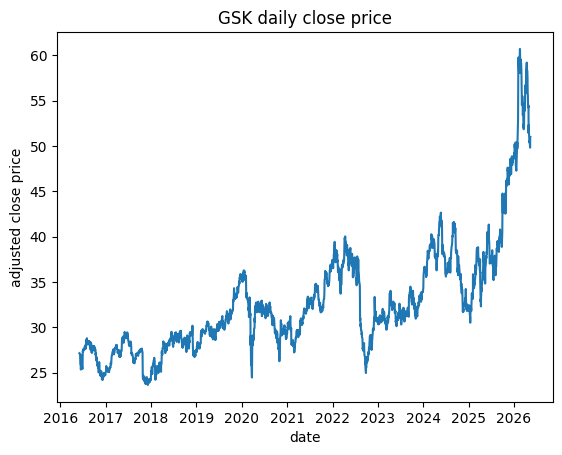

In [6]:
plt.plot(prices.index, prices["Close"])
plt.xlabel("date")
plt.ylabel("adjusted close price")
plt.title(f"{TICKER} daily close price")
plt.show()

# ─────────────────────────────────────────────
# 2. DAILY LOG RETURNS  =  log(Close_t / Close_{t-1})
# ─────────────────────────────────────────────

In [7]:
returns = pd.DataFrame(index=prices.index)
returns["Close"]       = prices["Close"]
returns["Log_Return"]  = np.log(prices["Close"] / prices["Close"].shift(1))
returns.dropna(inplace=True)          # Drop the first row (no previous close)

print(f"\n── Log Returns ({len(returns)} rows) ──")
print(returns.tail())


── Log Returns (2499 rows) ──
                Close  Log_Return
Date                             
2026-05-07  50.500000   -0.000594
2026-05-08  50.410000   -0.001784
2026-05-11  49.810001   -0.011974
2026-05-12  50.900002    0.021647
2026-05-13  50.990002    0.001767


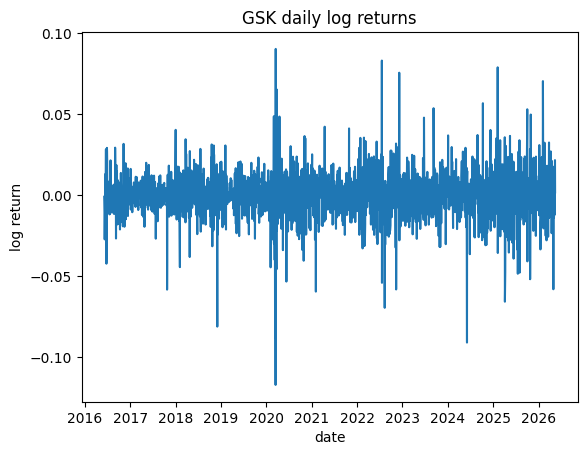

In [8]:
plt.plot(returns.index, returns["Log_Return"])
plt.xlabel("date")
plt.ylabel("log return")
plt.title(f"{TICKER} daily log returns")
plt.show()

# ─────────────────────────────────────────────
# 3. HISTOGRAM OF DAILY LOG RETURNS
# ─────────────────────────────────────────────

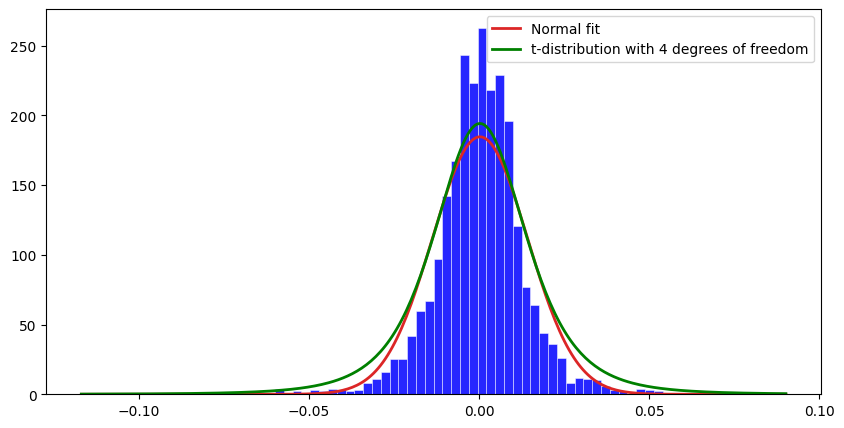

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    returns["Log_Return"],
    bins=80,
    color= "blue", #"#2563EB",
    edgecolor="white",
    linewidth=0.4,
    alpha=0.85
)

# Overlay a normal-distribution curve for reference
mu_all   = returns["Log_Return"].mean()
sig_all  = returns["Log_Return"].std()
x        = np.linspace(returns["Log_Return"].min(), returns["Log_Return"].max(), 300)
pdf      = (np.exp(-0.5 * ((x - mu_all) / sig_all) ** 2)
            / (sig_all * np.sqrt(2 * np.pi)))
pdf_scaled = pdf * len(returns) * (returns["Log_Return"].max() - returns["Log_Return"].min()) / 80
ax.plot(x, pdf_scaled, color="#DC2626", linewidth=2, label="Normal fit")

# Overlay a student t-distribution (4 degrees of freedom) curve for reference
num_df_t = 4
mu_all   = returns["Log_Return"].mean()
sig_all  = returns["Log_Return"].std()
x_t        = np.linspace(returns["Log_Return"].min(), returns["Log_Return"].max(), 300)
#print(x_t.max(), x_t.min())
pdf_t = t.pdf(((x_t - mu_all) / sig_all), num_df_t)
pdf_t_scaled = 80.0 * pdf_t * len(returns) * (returns["Log_Return"].max() - returns["Log_Return"].min()) / 80
ax.plot(x_t, pdf_t_scaled, color="green", linewidth=2, label="t-distribution with " + str(num_df_t) + " degrees of freedom")

ax.legend()

# ─────────────────────────────────────────────
# 4. ROLLING 100-DAY Z-SCORES
#    For each day t:
#      - look at the 100 days BEFORE t  (window = t-100 … t-1)
#      - compute $\mu$ and $\sigma$ of those returns
#      - $Z_t = (r_t - \mu) / \sigma$
# ─────────────────────────────────────────────

In [10]:
WINDOW = 100

zscores = returns.copy()

In [11]:
# .shift(1) shifts the window so it ends at t-1 (excludes today)
zscores["Rolling_Mu"]    = (
    zscores["Log_Return"]
    .shift(1)                       # exclude current day
    .rolling(window=WINDOW)         # look back WINDOW days
    .mean()
)
zscores["Rolling_Sigma"] = (
    zscores["Log_Return"]
    .shift(1)
    .rolling(window=WINDOW)
    .std()
)
zscores["Z_Score"] = (
    (zscores["Log_Return"] - zscores["Rolling_Mu"]) / zscores["Rolling_Sigma"]
)

# Drop rows where we don't yet have a full 100-day window
zscores.dropna(inplace=True)

print(f"\n── Z-Score DataFrame ({len(zscores)} rows) ──")
print(zscores[["Log_Return", "Rolling_Mu", "Rolling_Sigma", "Z_Score"]].tail(10).to_string())


── Z-Score DataFrame (2399 rows) ──
            Log_Return  Rolling_Mu  Rolling_Sigma   Z_Score
Date                                                       
2026-04-30    0.017549    0.000564       0.017208  0.987021
2026-05-01   -0.013472    0.000822       0.017268 -0.827767
2026-05-04   -0.013853    0.000720       0.017323 -0.841254
2026-05-05   -0.010269    0.000569       0.017384 -0.623457
2026-05-06    0.002973    0.000717       0.017226  0.130941
2026-05-07   -0.000594    0.000509       0.017068 -0.064602
2026-05-08   -0.001784    0.000406       0.017044 -0.128494
2026-05-11   -0.011974    0.000403       0.017044 -0.726147
2026-05-12    0.021647    0.000195       0.017067  1.256890
2026-05-13    0.001767    0.000506       0.017173  0.073428


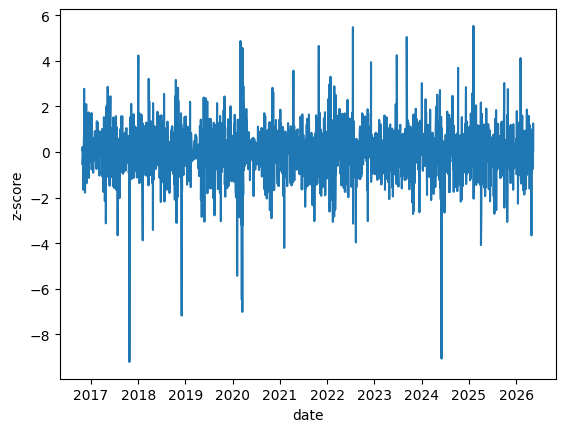

In [12]:
plt.plot(zscores.index,zscores["Z_Score"])
plt.xlabel("date")
plt.ylabel("z-score")
plt.show()

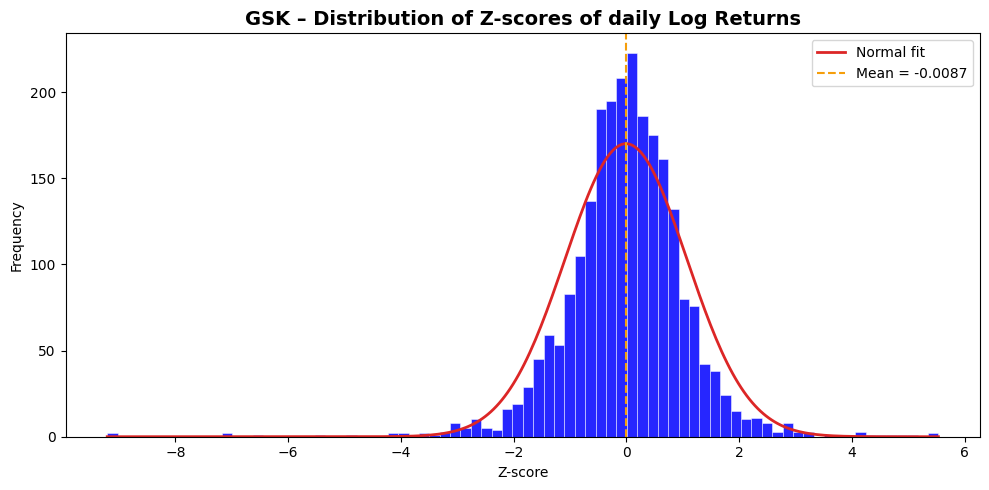

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    zscores["Z_Score"],
    bins=80,
    color= "blue", #"#2563EB",
    edgecolor="white",
    linewidth=0.4,
    alpha=0.85,
)

# Overlay a normal-distribution curve for reference
mu_all   = zscores["Z_Score"].mean()
sig_all  = zscores["Z_Score"].std()
x        = np.linspace( zscores["Z_Score"].min(),  zscores["Z_Score"].max(), 300)
pdf      = (np.exp(-0.5 * ((x - mu_all) / sig_all) ** 2)
            / (sig_all * np.sqrt(2 * np.pi)))
pdf_scaled = pdf * len(returns) * ( zscores["Z_Score"].max() -  zscores["Z_Score"].min()) / 80
ax.plot(x, pdf_scaled, color="#DC2626", linewidth=2, label="Normal fit")

ax.axvline(mu_all, color="#F59E0B", linewidth=1.5, linestyle="--", label=f"Mean = {mu_all:.4f}")
ax.set_title(f"{TICKER} – Distribution of Z-scores of daily Log Returns", fontsize=14, fontweight="bold")
ax.set_xlabel("Z-score")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
#plt.savefig("/mnt/user-data/outputs/returns_histogram.png", dpi=150)
plt.show()